# Tutorial 6 — Attention on Structured Geometric Data

**MM845 — Tópicos de Geometria III: AI for Geometry**
Paired with **Lecture 6: Transformers and Attention**

---

A convolution (Tutorial 5) fixes its neighbourhood in advance: pixel $(i,j)$ talks to
$(i\pm1, j\pm1)$, always, because the grid says so. Much geometric data has no grid.
A point cloud, a set of simplices, the vertices of a triangulation — these are
**sets**, and the only structure available is what the data itself supplies.

Attention is the operator for that situation. It computes, from the data, *which
elements should talk to which*, and then averages accordingly. Its native symmetry is
not translation but **permutation**: relabel the elements and the output relabels
with them.

| § | Question |
|---|---|
| 1 | Attention as a permutation-equivariant operator on a set |
| 2 | A geometric task where order is meaningless |
| 3 | Attention vs an MLP that sees the same points in some order |
| 4 | Reading the attention weights: what does the model look at? |
| 5 | Summary |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

SEED = 20260910
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)

GEO_DARK, GEO_TEAL, GEO_RUST = "#103158", "#006c86", "#b2461e"
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.titlesize": 10,
                     "axes.grid": True, "grid.alpha": 0.25,
                     "axes.prop_cycle": plt.cycler(color=[GEO_DARK, GEO_TEAL, GEO_RUST])})
print("torch", torch.__version__)

torch 2.13.0+cpu


---
## 1. Attention, and the symmetry it respects

Given $n$ elements with feature vectors $x_1,\dots,x_n \in \mathbb{R}^d$, stacked as
$X \in \mathbb{R}^{n\times d}$, **scaled dot-product attention** forms three linear
images of the data and mixes them:

$$Q = XW_Q, \quad K = XW_K, \quad V = XW_V,
\qquad
\mathrm{Att}(X) \;=\; \underbrace{\mathrm{softmax}\!\Big(\tfrac{QK^\top}{\sqrt{d_k}}\Big)}_{A \;\in\; \mathbb{R}^{n\times n}} V .$$

The matrix $A$ is row-stochastic: row $i$ is a probability distribution over the
other elements, saying how much element $i$ attends to each. Two things follow.

- **Attention is a data-dependent averaging operator.** Convolution also averages
  neighbours, but with weights fixed by the architecture; here $A$ is computed from
  $X$ and changes with every input. This is the sense in which the neighbourhood is
  *learned* rather than declared.
- **Attention is permutation-equivariant.** For a permutation matrix $P$,
  $\mathrm{Att}(PX) = P\,\mathrm{Att}(X)$: the entries of $A$ are functions of pairs
  $(x_i, x_j)$ only, so permuting the input permutes the rows and columns of $A$ in
  step. There is nothing in the formula that knows about order.

That last point is why attention suits sets. It is also why transformers need
*positional encoding* when order does matter — the mechanism has no access to it
otherwise, and it must be supplied as part of the features.

In [2]:
def attention(X, Wq, Wk, Wv, return_weights=False):
    """Scaled dot-product attention, written out."""
    Q, K, V = X @ Wq, X @ Wk, X @ Wv
    scores = Q @ K.transpose(-2, -1) / np.sqrt(K.shape[-1])
    A = torch.softmax(scores, dim=-1)
    out = A @ V
    return (out, A) if return_weights else out


n, d, dk = 6, 4, 8
X = torch.tensor(rng.normal(size=(n, d)))
Wq, Wk, Wv = (torch.tensor(rng.normal(size=(d, dk)) * 0.5) for _ in range(3))

perm = torch.tensor(rng.permutation(n))
P = torch.eye(n, dtype=torch.float64)[perm]

out, A = attention(X, Wq, Wk, Wv, return_weights=True)
out_perm = attention(P @ X, Wq, Wk, Wv)

print(f"rows of A sum to 1:            {A.sum(dim=1).numpy().round(12)}")
print(f"permutation equivariance:      ||Att(PX) - P Att(X)||_inf = "
      f"{(out_perm - P @ out).abs().max():.2e}")
print(f"a global mean gives invariance: ||mean Att(PX) - mean Att(X)||_inf = "
      f"{(out_perm.mean(0) - out.mean(0)).abs().max():.2e}")

rows of A sum to 1:            [1. 1. 1. 1. 1. 1.]
permutation equivariance:      ||Att(PX) - P Att(X)||_inf = 1.11e-16
a global mean gives invariance: ||mean Att(PX) - mean Att(X)||_inf = 2.78e-17


---
## 2. A task where order is meaningless

We need a label that depends on a point cloud as a **set**, not as a list. Take $n$
points sampled in the plane and ask for the **diameter**,

$$\mathrm{diam}(S) \;=\; \max_{i,j} \lVert x_i - x_j \rVert ,$$

which is exact, cheap to compute, permutation-invariant, and — importantly —
depends on only two of the $n$ points. A model must *find* the relevant pair, which
is precisely the kind of relational question attention is built for.

The clouds are sampled from random ellipses, so the extreme pair is usually well
separated from the rest.

One detail matters enormously and is easy to skip past: **the points arrive sorted
by angle**. That is a perfectly natural way for such data to reach you — traversal
order around a boundary, a scan order, the order a solver emitted. It means the
input carries a real, learnable ordering, which is exactly the situation in which
the choice of architecture starts to bite.

clouds (6000, 16, 2),  diameter in [0.84, 2.11]
predict-the-mean baseline MSE: 0.0761


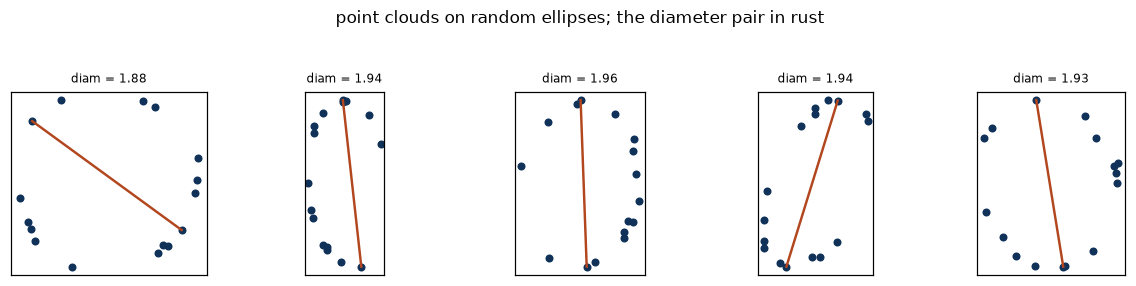

In [3]:
N_PTS = 16


def make_clouds(n_sets, rng, n_pts=N_PTS):
    """Point clouds on random ellipses, labelled by their diameter."""
    ang = np.sort(rng.uniform(0, 2 * np.pi, size=(n_sets, n_pts)), axis=1)
    a = rng.uniform(0.4, 1.0, size=(n_sets, 1))
    b = rng.uniform(0.4, 1.0, size=(n_sets, 1))
    th = rng.uniform(0, np.pi, size=(n_sets, 1))
    x = a * np.cos(ang); y = b * np.sin(ang)
    X = np.stack([x * np.cos(th) - y * np.sin(th),
                  x * np.sin(th) + y * np.cos(th)], axis=-1)
    X += 0.03 * rng.normal(size=X.shape)
    D = np.linalg.norm(X[:, :, None, :] - X[:, None, :, :], axis=-1)
    diam = D.max(axis=(1, 2))
    return X.astype(np.float32), diam.astype(np.float32), D


Xtr, ytr, _ = make_clouds(6000, rng)
Xte, yte, Dte = make_clouds(1500, rng)
print(f"clouds {Xtr.shape},  diameter in [{ytr.min():.2f}, {ytr.max():.2f}]")
print(f"predict-the-mean baseline MSE: {np.mean((yte - ytr.mean())**2):.4f}")

fig, axes = plt.subplots(1, 5, figsize=(11.0, 2.4))
for j, ax in enumerate(axes):
    i, jj = np.unravel_index(np.argmax(Dte[j]), Dte[j].shape)
    ax.scatter(*Xte[j].T, s=18, color=GEO_DARK)
    ax.plot(Xte[j][[i, jj], 0], Xte[j][[i, jj], 1], color=GEO_RUST, lw=1.6)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"diam = {yte[j]:.2f}", fontsize=8)
fig.suptitle("point clouds on random ellipses; the diameter pair in rust", y=1.06)
plt.tight_layout(); plt.show()

---
## 3. Attention versus a model that sees an ordering

Two architectures, same data:

- **Set-attention model.** Embed each point, apply one attention block, take the
  **mean over points** (making it permutation-invariant), and read off the answer
  with a small head. About as small as a transformer gets.
- **MLP on the flattened cloud.** Concatenate the $n$ points into a vector of length
  $2n$ and apply a dense network. This model sees an ordering, and has no reason to
  suspect it is meaningless.

At test time we evaluate both on the ordinary test set and on a **shuffled** copy in
which every cloud's points have been randomly reordered. The label does not change.

In [4]:
class SetAttention(nn.Module):
    def __init__(self, d_model=32):
        super().__init__()
        self.embed = nn.Sequential(nn.Linear(2, d_model), nn.ReLU(),
                                   nn.Linear(d_model, d_model))
        self.Wq = nn.Linear(d_model, d_model, bias=False)
        self.Wk = nn.Linear(d_model, d_model, bias=False)
        self.Wv = nn.Linear(d_model, d_model, bias=False)
        self.ff = nn.Sequential(nn.Linear(d_model, d_model), nn.ReLU())
        self.head = nn.Sequential(nn.Linear(d_model, d_model), nn.ReLU(),
                                  nn.Linear(d_model, 1))

    def forward(self, x, return_A=False):
        h = self.embed(x)
        q, k, v = self.Wq(h), self.Wk(h), self.Wv(h)
        A = torch.softmax(q @ k.transpose(1, 2) / np.sqrt(k.shape[-1]), dim=-1)
        h = h + self.ff(A @ v)                    # attention block with a residual
        out = self.head(h.mean(dim=1))            # mean over points -> invariance
        return (out, A) if return_A else out


class FlatMLP(nn.Module):
    def __init__(self, width=128):
        super().__init__()
        self.net = nn.Sequential(nn.Flatten(), nn.Linear(2 * N_PTS, width), nn.ReLU(),
                                 nn.Linear(width, width), nn.ReLU(),
                                 nn.Linear(width, width), nn.ReLU(),
                                 nn.Linear(width, 1))

    def forward(self, x):
        return self.net(x)


def train(model, X, y, epochs=60, bs=256, lr=3e-3):
    Xt = torch.tensor(X); yt = torch.tensor(y).unsqueeze(1)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.MSELoss()
    for ep in range(epochs):
        perm = torch.randperm(len(Xt))
        for i in range(0, len(Xt), bs):
            idx = perm[i:i + bs]
            opt.zero_grad(); lossf(model(Xt[idx]), yt[idx]).backward(); opt.step()
    return model


def mse(model, X, y):
    with torch.no_grad():
        return float(np.mean((model(torch.tensor(X)).numpy().ravel() - y)**2))


nparams = lambda m: sum(p.numel() for p in m.parameters())

# a shuffled copy of the test set: same sets, different order
Xte_sh = np.stack([c[rng.permutation(N_PTS)] for c in Xte])

In [5]:
torch.manual_seed(0); att = train(SetAttention(), Xtr, ytr)
torch.manual_seed(0); mlp = train(FlatMLP(), Xtr, ytr)

base = np.mean((yte - ytr.mean())**2)
print(f"predict-the-mean baseline   MSE {base:.4f}\n")
print(f"  {'model':18s} {'params':>8s} {'test MSE':>10s} {'shuffled':>11s}")
for name, m in [("set attention", att), ("MLP on flattened", mlp)]:
    print(f"  {name:18s} {nparams(m):8,d} {mse(m, Xte, yte):10.5f} {mse(m, Xte_sh, yte):11.5f}")

predict-the-mean baseline   MSE 0.0761

  model                params   test MSE    shuffled
  set attention         6,369    0.00109     0.00109
  MLP on flattened     37,377    0.00517     0.06346


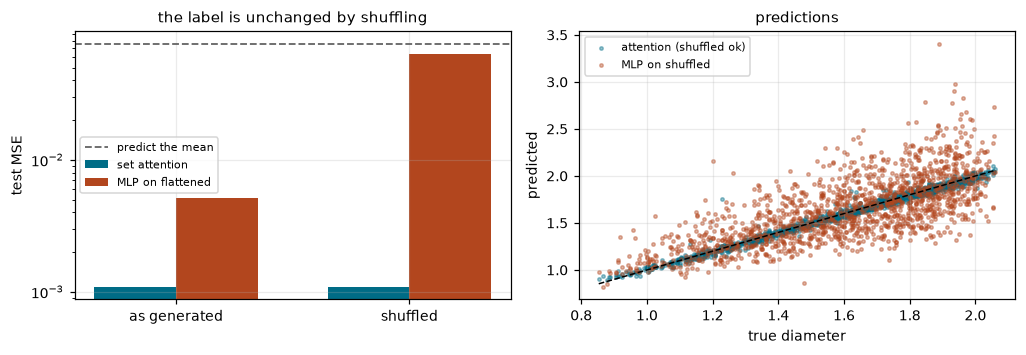

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.3))
w = 0.35
vals = {"set attention": [mse(att, Xte, yte), mse(att, Xte_sh, yte)],
        "MLP on flattened": [mse(mlp, Xte, yte), mse(mlp, Xte_sh, yte)]}
for k, (name, col) in enumerate([("set attention", GEO_TEAL), ("MLP on flattened", GEO_RUST)]):
    axes[0].bar(np.arange(2) + (k - 0.5) * w, vals[name], w, label=name, color=col)
axes[0].axhline(base, color="0.4", ls="--", lw=1.2, label="predict the mean")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["as generated", "shuffled"])
axes[0].set_yscale("log"); axes[0].set_ylabel("test MSE")
axes[0].set_title("the label is unchanged by shuffling"); axes[0].legend(fontsize=7.5)

with torch.no_grad():
    pa = att(torch.tensor(Xte)).numpy().ravel()
    pm = mlp(torch.tensor(Xte_sh)).numpy().ravel()
axes[1].scatter(yte, pa, s=5, alpha=0.4, color=GEO_TEAL, label="attention (shuffled ok)")
axes[1].scatter(yte, pm, s=5, alpha=0.4, color=GEO_RUST, label="MLP on shuffled")
lims = [yte.min(), yte.max()]
axes[1].plot(lims, lims, "k--", lw=1)
axes[1].set_xlabel("true diameter"); axes[1].set_ylabel("predicted")
axes[1].legend(fontsize=7.5); axes[1].set_title("predictions")
plt.tight_layout(); plt.show()

The attention model is **exactly** unaffected by shuffling — not approximately but
to the last digit, because permutation invariance is an algebraic property of
`softmax(QK^T)V` followed by a mean, not something it learned.

The MLP tells the more interesting story. On sorted input it is respectable: with
points ordered by angle, the diameter pair sits at roughly opposite indices, and a
dense network can exploit that regularity. Shuffle the points and the regularity
evaporates. Nothing about the *geometry* changed — same points, same diameter — only
the labelling, which was never information in the first place.

This is Tutorial 5's lesson with a different group. There the symmetry was
translation and the fix was convolution; here it is $S_n$ and the fix is attention
(or, more cheaply, any pooling over a shared per-point map — the DeepSets
construction). Lecture 10 gives the general statement.

> **Exercise 1 — how much structure do you actually need?**
> (a) Replace attention by **DeepSets**: embed each point with a shared MLP, sum
> over points, apply a head. That is permutation-invariant too, and has no
> $n\times n$ interaction. How close does it get on the diameter, and why might it
> struggle?
>
> (b) Sort the points (by angle, say) before feeding the MLP. Sorting is a cheap way
> to make a set canonical. Does it fix the MLP, and what has it cost you?
>
> (c) Change the label to the **mean pairwise distance** instead of the maximum. One
> of these tasks needs to identify a specific pair and one does not — which model's
> advantage shrinks?

---
## 4. What is the model attending to?

The matrix $A$ is interpretable in a way that most learned objects are not: row $i$
is an honest probability distribution over points, and we can plot it. For a
diameter task there is a clear hypothesis to test — the model should care about
the extreme points and ignore the interior.

We measure this directly. For each cloud, compute how much total attention each
point receives (the column sums of $A$), and compare that with the point's
**eccentricity**: its distance from the cloud's centroid.

In [7]:
with torch.no_grad():
    _, A = att(torch.tensor(Xte[:400]), return_A=True)
A = A.numpy()

recv = A.sum(axis=1)                                   # attention received per point
cen = Xte[:400] - Xte[:400].mean(axis=1, keepdims=True)
ecc = np.linalg.norm(cen, axis=-1)                     # distance from the centroid

# is the extreme pair attended to more than average?
is_extreme = np.zeros_like(ecc, dtype=bool)
for s in range(400):
    d = np.linalg.norm(Xte[s][:, None] - Xte[s][None, :], axis=-1)
    i, j = np.unravel_index(np.argmax(d), d.shape)
    is_extreme[s, [i, j]] = True

corr = np.corrcoef(ecc.ravel(), recv.ravel())[0, 1]
print(f"correlation(attention received, distance from centroid) = {corr:+.3f}")
print(f"mean attention received by the diameter pair : {recv[is_extreme].mean():.3f}")
print(f"mean attention received by all other points : {recv[~is_extreme].mean():.3f}")
print(f"ratio: {recv[is_extreme].mean() / recv[~is_extreme].mean():.2f}x")

correlation(attention received, distance from centroid) = +0.441
mean attention received by the diameter pair : 3.323
mean attention received by all other points : 0.668
ratio: 4.97x


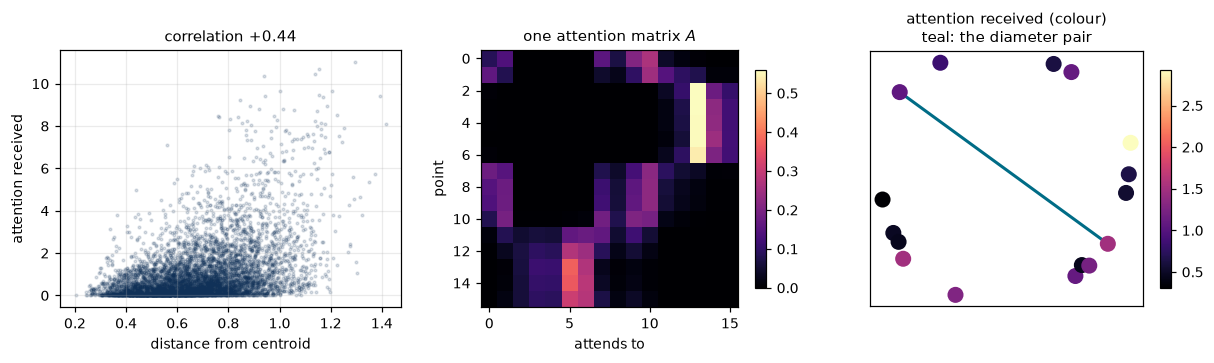

In [8]:
fig = plt.figure(figsize=(11.2, 3.2))

ax = fig.add_subplot(131)
ax.scatter(ecc.ravel(), recv.ravel(), s=3, alpha=0.15, color=GEO_DARK)
ax.set_xlabel("distance from centroid"); ax.set_ylabel("attention received")
ax.set_title(f"correlation {corr:+.2f}")

ax = fig.add_subplot(132)
im = ax.imshow(A[0], cmap="magma")
ax.set_xlabel("attends to"); ax.set_ylabel("point")
ax.set_title("one attention matrix $A$"); ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.85)

ax = fig.add_subplot(133)
s = 0
d = np.linalg.norm(Xte[s][:, None] - Xte[s][None, :], axis=-1)
i, j = np.unravel_index(np.argmax(d), d.shape)
sc = ax.scatter(*Xte[s].T, c=recv[s], s=90, cmap="magma", zorder=3)
ax.plot(Xte[s][[i, j], 0], Xte[s][[i, j], 1], color=GEO_TEAL, lw=2, zorder=2)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title("attention received (colour)\nteal: the diameter pair")
fig.colorbar(sc, ax=ax, shrink=0.85)
plt.tight_layout(); plt.show()

Read the numbers before the pictures — and here they support the hypothesis. The
diameter pair receives several times the attention of an average point, and
attention received correlates positively with distance from the centroid. The model
has, without being told, learned to look at the extremes.

That is a genuinely satisfying result, so it is the right moment to say why it is
not proof. Attention maps are the most over-interpreted objects in modern machine
learning: they are inspectable, which tempts one to read them as explanations, and
there is a substantial literature showing that attention weights and causal
importance can come apart. What we have measured is a *correlation* between
attention and a quantity we believe matters. What would settle it is an
intervention — suppress the attention paid to those points and see whether the
prediction actually degrades. That is Exercise 2(a), and you should do it before
believing this figure.

The discipline is the same as in Tutorial 5 §4: state a hypothesis about what the
model should attend to, compute a number that could refute it, and then check that
the number is measuring what you think.

> **Exercise 2 — attention, tested rather than admired.**
> (a) **Ablation.** Zero out the attention a cloud pays to its two extreme points and
> measure how much the prediction changes; compare with zeroing two random points. If
> the extremes matter causally, the two should differ.
>
> (b) Train on the **mean** pairwise distance instead of the diameter and recompute
> the ratio above. A task with no special pair should show even less concentration —
> does it?
>
> (c) Add a second attention layer and re-measure. Does depth sharpen the attention
> onto the relevant pair, and does test error improve alongside it?

> **Exercise 3 — when order does matter.**
> Attention alone cannot see order, which is why transformers add positional
> encodings. Build a task where order carries the answer: treat each cloud as the
> vertex sequence of a closed polygon and predict its **signed area**
> $\frac12\sum_i (x_i y_{i+1} - x_{i+1} y_i)$, which changes sign if you reverse the
> traversal. Show that the set model cannot do better than chance on the sign, then
> add a positional encoding to the point features and watch it become solvable.

---
## 5. What to take away

- Attention is a **data-dependent averaging operator**: the same shape as a
  convolution, but with the neighbourhood computed from the input rather than fixed
  by a grid. That is what lets it act on sets, graphs, and simplicial data.
- Its native symmetry is **permutation**, and the invariance is algebraic — a model
  built from attention plus a mean is exactly invariant, not approximately.
- **The symmetry mismatch is the whole story.** An MLP on a flattened cloud extracts
  information from an ordering that carries none, and pays for it the moment the
  ordering changes.
- Attention needs **positional encoding** precisely because it cannot see order. When
  the geometry does have an order — a filtration, a boundary traversal — you must
  supply it as a feature.
- **Attention maps are evidence, not explanations.** Test them with ablations before
  believing the picture.

### Next

**Lecture 7** leaves supervised learning behind: with no labels at all, what
structure can be recovered from a point cloud? **Tutorial 7** uses clustering to
detect connected components and geometric phases.

### Further reading

- Vaswani et al., "Attention is all you need", *NeurIPS* 2017 — the original.
- Zaheer et al., "Deep Sets", *NeurIPS* 2017 — the minimal permutation-invariant architecture of Exercise 1(a).
- Lee et al., "Set Transformer", *ICML* 2019 — attention designed for sets, and the model §3 is a stripped-down version of.
- Jain & Wallace, "Attention is not explanation", *NAACL* 2019 — the caution in §4.